# ResNet 实践教程

本 Notebook 配合理论教程使用，涵盖：
1. 环境配置与数据准备
2. 残差块与 ResNet-18 实现
3. 训练与评估
4. 消融实验：有无跳跃连接的对比
5. 迁移学习实践


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np

# 固定随机种子，保证可复现
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备：{DEVICE}")

使用设备：cpu


## 1. 数据准备

使用 CIFAR-10 数据集（32×32 彩色图像，10 类）。
训练集使用随机裁剪 + 水平翻转做数据增强，测试集只做归一化。
均值和标准差来自 CIFAR-10 统计量。


In [25]:
# CIFAR-10 的均值和标准差
MEAN = (0.4914, 0.4822, 0.4465)
STD = (0.2023, 0.1994, 0.2010)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

train_set = datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=transform_train)
test_set = datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)

# 只用 5000 张训练图，加快实验速度
train_subset = torch.utils.data.Subset(train_set, range(5000))

# num_workers 增加到 4，利用多核 CPU
train_loader = DataLoader(train_subset, batch_size=128,
                          shuffle=True,  num_workers=4, pin_memory=False)
test_loader = DataLoader(test_set,     batch_size=256,
                         shuffle=False, num_workers=4, pin_memory=False)

CLASSES = train_set.classes
print(f"训练集大小：{len(train_subset)}，测试集大小：{len(test_set)}")
print(f"类别：{CLASSES}")

训练集大小：5000，测试集大小：10000
类别：['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


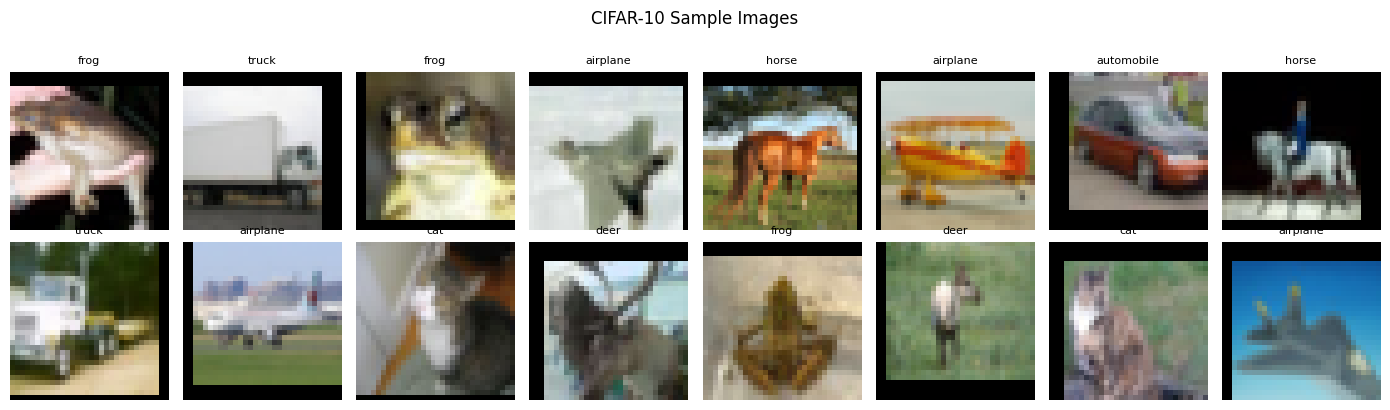

In [26]:
# 可视化一批样本，确认数据加载正确
def denormalize(tensor, mean=MEAN, std=STD):
    """反归一化，用于可视化"""
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)


images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('CIFAR-10 Sample Images', y=1.02)
plt.tight_layout()
plt.show()

## 2. 残差块实现

### 2.1 BasicBlock

核心公式：$y = \text{ReLU}(\mathcal{F}(x, \{W_i\}) + x)$

关键细节：

- BN 在 ReLU 之前
- 最后一个 BN 之后**不加** ReLU，加法之后才激活
- 维度不匹配时用 1×1 卷积投影


In [27]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, use_shortcut=True):
        super().__init__()
        self.use_shortcut = use_shortcut

        # 主路径：两个 3×3 卷积
        self.conv1 = nn.Conv2d(in_channels, out_channels,
                               3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 跳跃连接：维度匹配时为恒等映射，否则用 1×1 卷积投影
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.use_shortcut:
            out = out + self.shortcut(x)   # 残差相加

        out = F.relu(out)
        return out


# 快速验证：输入 (B=2, C=64, H=32, W=32)，步长=2 时输出尺寸减半
block = BasicBlock(64, 128, stride=2)
x_test = torch.randn(2, 64, 32, 32)
print(f"输入形状：{x_test.shape}")
print(f"输出形状：{block(x_test).shape}")   # 期望 (2, 128, 16, 16)

输入形状：torch.Size([2, 64, 32, 32])
输出形状：torch.Size([2, 128, 16, 16])


### 2.2 完整 ResNet-18

针对 CIFAR-10（32×32）做了一处调整：
将第一层卷积从 7×7 stride=2 改为 3×3 stride=1，去掉 MaxPool，
避免小尺寸图像在网络入口就损失过多空间信息。


In [29]:
class ResNet8(nn.Module):
    """轻量版 ResNet，适合 CPU 快速实验，保留核心结构"""
    def __init__(self, num_classes=10, use_shortcut=True):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.in_channels  = 32  # 通道数减半

        # CIFAR-10 适配：3×3 卷积，不做下采样
        self.conv1 = nn.Conv2d(3, 32, 3, 1, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(32)

        # 每层只用 1 个块，减少计算量
        self.layer1 = self._make_layer(32,  1, stride=1)
        self.layer2 = self._make_layer(64,  1, stride=2)
        self.layer3 = self._make_layer(128, 1, stride=2)
        self.layer4 = self._make_layer(256, 1, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(256, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride, self.use_shortcut))
        self.in_channels = out_channels
        for _ in range(num_blocks - 1):
            layers.append(BasicBlock(out_channels, out_channels, stride=1, use_shortcut=self.use_shortcut))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


model = ResNet8(num_classes=10).to(DEVICE)

# 统计参数量
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ResNet-8 可训练参数量：{total_params / 1e6:.2f}M")


ResNet-8 可训练参数量：1.23M


## 3. 训练与评估

训练配置（CPU 优化版）：

- 优化器：SGD，momentum=0.9，weight_decay=5e-4
- 初始学习率：0.1，每 30 epoch 乘以 0.1
- 使用 ResNet-8（轻量版）+ 5000 张训练图 + 10 个 epoch
- 重点观察有无跳跃连接的对比，而非追求最高准确率


In [30]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += outputs.argmax(1).eq(targets).sum().item()
        total += targets.size(0)

    return total_loss / len(loader), 100.0 * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            total_loss += criterion(outputs, targets).item()
            correct += outputs.argmax(1).eq(targets).sum().item()
            total += targets.size(0)

    return total_loss / len(loader), 100.0 * correct / total

In [31]:
def run_training(model, train_loader, test_loader, device,
                 lr=0.1, num_epochs=10, step_size=30):  # 改成 10 个 epoch
    """封装完整训练流程，返回历史记录"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr,
                          momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.StepLR(
        optimizer, step_size=step_size, gamma=0.1)

    history = {'train_loss': [], 'train_acc': [],
               'test_loss': [], 'test_acc': []}

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)

        print(f"Epoch {epoch:02d}/{num_epochs}  "
              f"Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.1f}%  "
              f"Test Loss: {te_loss:.4f}  Test Acc: {te_acc:.1f}%")

    return history


# 训练 ResNet-8（有跳跃连接）
print("=" * 60)
print("训练 ResNet-8（有跳跃连接）")
print("=" * 60)
model_with = ResNet8(use_shortcut=True).to(DEVICE)
history_with = run_training(model_with, train_loader, test_loader, DEVICE)

训练 ResNet-8（有跳跃连接）
Epoch 01/10  Train Loss: 2.0649  Train Acc: 24.1%  Test Loss: 2.9641  Test Acc: 22.3%
Epoch 02/10  Train Loss: 1.8809  Train Acc: 29.5%  Test Loss: 2.0601  Test Acc: 28.2%
Epoch 03/10  Train Loss: 1.6900  Train Acc: 36.1%  Test Loss: 1.7533  Test Acc: 33.8%
Epoch 04/10  Train Loss: 1.6392  Train Acc: 38.9%  Test Loss: 1.6336  Test Acc: 41.6%
Epoch 05/10  Train Loss: 1.5343  Train Acc: 43.1%  Test Loss: 1.5358  Test Acc: 43.6%
Epoch 06/10  Train Loss: 1.4786  Train Acc: 45.4%  Test Loss: 1.4568  Test Acc: 46.2%
Epoch 07/10  Train Loss: 1.4332  Train Acc: 46.5%  Test Loss: 1.4795  Test Acc: 45.4%
Epoch 08/10  Train Loss: 1.3860  Train Acc: 47.9%  Test Loss: 1.4449  Test Acc: 47.0%
Epoch 09/10  Train Loss: 1.3802  Train Acc: 49.0%  Test Loss: 1.5078  Test Acc: 47.3%
Epoch 10/10  Train Loss: 1.3053  Train Acc: 52.3%  Test Loss: 1.4373  Test Acc: 49.4%


## 4. 消融实验：跳跃连接的作用

移除所有跳跃连接，其余结构完全相同，对比训练曲线。
这正是论文 Figure 5 所展示的实验设置。


In [33]:
print("=" * 60)
print("训练 ResNet-8-NS（无跳跃连接）")
print("=" * 60)
model_without = ResNet8(use_shortcut=False).to(DEVICE)
history_without = run_training(
    model_without, train_loader, test_loader, DEVICE)

训练 ResNet-8-NS（无跳跃连接）
Epoch 01/10  Train Loss: 1.9984  Train Acc: 24.8%  Test Loss: 2.4336  Test Acc: 25.7%
Epoch 02/10  Train Loss: 1.8749  Train Acc: 31.0%  Test Loss: 1.7882  Test Acc: 34.5%
Epoch 03/10  Train Loss: 1.7176  Train Acc: 35.6%  Test Loss: 1.8362  Test Acc: 34.6%
Epoch 04/10  Train Loss: 1.6895  Train Acc: 37.1%  Test Loss: 1.8454  Test Acc: 34.3%
Epoch 05/10  Train Loss: 1.6977  Train Acc: 37.6%  Test Loss: 1.6539  Test Acc: 38.8%
Epoch 06/10  Train Loss: 1.5687  Train Acc: 42.4%  Test Loss: 1.8252  Test Acc: 35.0%
Epoch 07/10  Train Loss: 1.5654  Train Acc: 42.3%  Test Loss: 1.5691  Test Acc: 42.3%
Epoch 08/10  Train Loss: 1.5258  Train Acc: 43.7%  Test Loss: 1.5290  Test Acc: 44.6%
Epoch 09/10  Train Loss: 1.4257  Train Acc: 47.5%  Test Loss: 1.5375  Test Acc: 45.0%
Epoch 10/10  Train Loss: 1.3661  Train Acc: 49.1%  Test Loss: 1.5484  Test Acc: 44.7%


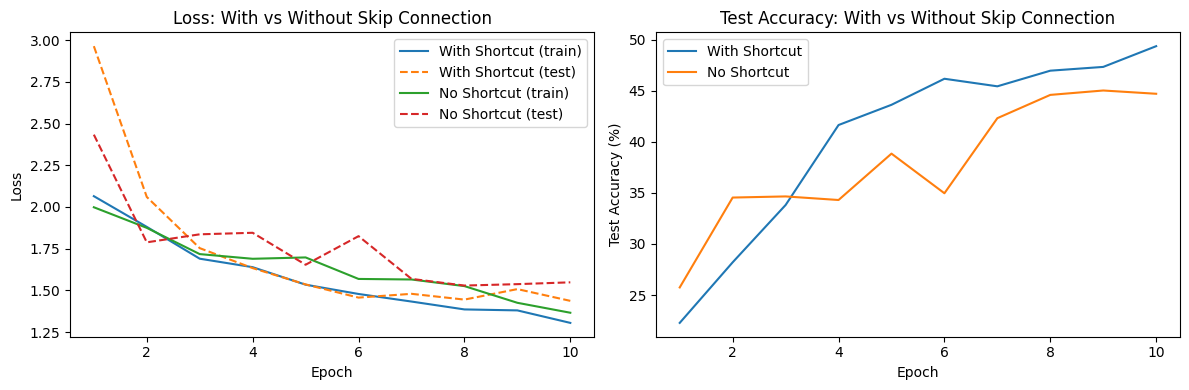


最终测试准确率（有跳跃连接）：49.4%
最终测试准确率（无跳跃连接）：44.7%


In [34]:
# 可视化对比：有 vs 无跳跃连接
epochs = range(1, len(history_with['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 损失曲线
axes[0].plot(epochs, history_with['train_loss'],
             label='With Shortcut (train)')
axes[0].plot(epochs, history_with['test_loss'],
             label='With Shortcut (test)', linestyle='--')
axes[0].plot(epochs, history_without['train_loss'],
             label='No Shortcut (train)')
axes[0].plot(epochs, history_without['test_loss'],
             label='No Shortcut (test)',   linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss: With vs Without Skip Connection')
axes[0].legend()

# 准确率曲线
axes[1].plot(epochs, history_with['test_acc'],     label='With Shortcut')
axes[1].plot(epochs, history_without['test_acc'],  label='No Shortcut')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Test Accuracy: With vs Without Skip Connection')
axes[1].legend()

plt.tight_layout()
plt.show()

# 打印最终结果
print(f"\n最终测试准确率（有跳跃连接）：{history_with['test_acc'][-1]:.1f}%")
print(f"最终测试准确率（无跳跃连接）：{history_without['test_acc'][-1]:.1f}%")

## 5. 梯度分析

观察各层梯度的平均绝对值，直观验证跳跃连接对梯度流动的改善。
梯度消失表现为越靠近输入层，梯度越接近 0。


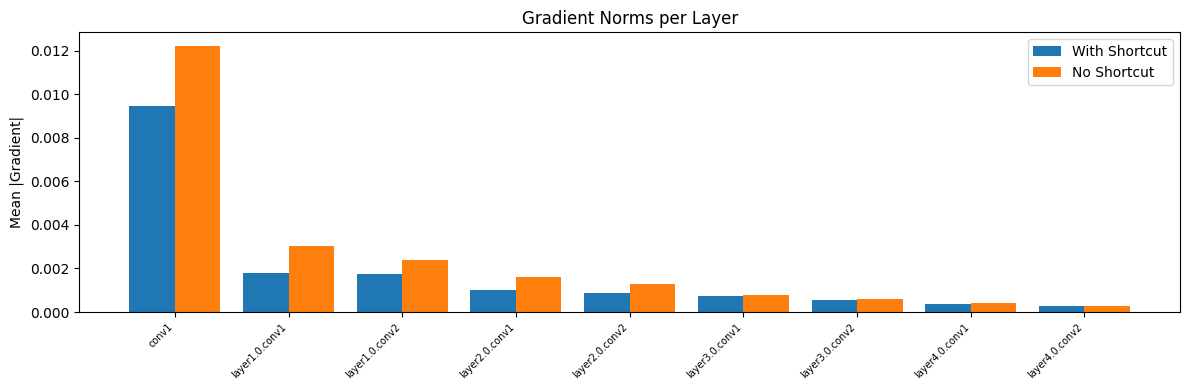

In [35]:
def get_gradient_norms(model, loader, criterion, device):
    """跑一个 batch，收集各层梯度的平均绝对值"""
    model.train()
    inputs, targets = next(iter(loader))
    inputs, targets = inputs.to(device), targets.to(device)

    model.zero_grad()
    loss = criterion(model(inputs), targets)
    loss.backward()

    grad_norms = {}
    for name, param in model.named_parameters():
        if param.grad is not None and 'conv' in name:
            grad_norms[name] = param.grad.abs().mean().item()
    return grad_norms


criterion = nn.CrossEntropyLoss()
norms_with = get_gradient_norms(model_with,    train_loader, criterion, DEVICE)
norms_without = get_gradient_norms(
    model_without, train_loader, criterion, DEVICE)

# 只取 conv 层，按网络深度排列
names = list(norms_with.keys())
vals_with = [norms_with[n] for n in names]
vals_without = [norms_without[n] for n in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - 0.2, vals_with,    0.4, label='With Shortcut')
ax.bar(x + 0.2, vals_without, 0.4, label='No Shortcut')
ax.set_xticks(x)
ax.set_xticklabels([n.replace('.weight', '')
                   for n in names], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Mean |Gradient|')
ax.set_title('Gradient Norms per Layer')
ax.legend()
plt.tight_layout()
plt.show()

## 4. 迁移学习实验

迁移学习的核心思想：

- 在较大数据集上预训练的模型已经学到了有用的特征表示
- 微调时只需调整最后的分类层，即可适配新任务（小数据量）

**实验设计**：

- "预训练模型"：前面用 5000 张图训练好的 ResNet-8
- "新任务"：只用 2000 张图训练（模拟小数据场景）
- 冻结卷积层，只训练全连接层
- 对比：使用预训练权重 vs 随机初始化（相同架构、相同训练策略）

**预期结果**：

- 预训练权重能显著提升小数据场景下的收敛速度和准确率


In [40]:
# 迁移学习数据准备（保持 32×32，匹配 ResNet-8）
from torch.utils.data import Subset

# 模拟新任务：只用 2000 张训练图
train_sub = Subset(
    datasets.CIFAR10('./data', train=True,  transform=transform_train),
    indices=range(2000)
)
test_sub = Subset(
    datasets.CIFAR10('./data', train=False, transform=transform_test),
    indices=range(500)
)

transfer_train_loader = DataLoader(
    train_sub, batch_size=128, shuffle=True,  num_workers=4)
transfer_test_loader = DataLoader(
    test_sub,  batch_size=256, shuffle=False, num_workers=4)

print(f"迁移学习训练集：{len(train_sub)} 张，测试集：{len(test_sub)} 张")

迁移学习训练集：2000 张，测试集：500 张


In [41]:
import copy

# 使用前面训练好的 ResNet-8 作为"预训练模型"
print("=" * 60)
print("迁移学习：使用训练好的 ResNet-8 权重")
print("=" * 60)

# 深拷贝训练好的模型（避免修改原模型）
transfer_model = copy.deepcopy(model_with)

# 冻结所有卷积层和 BN 层
for name, param in transfer_model.named_parameters():
    if 'fc' not in name:  # 只保留 fc 层可训练
        param.requires_grad = False

# 重新初始化 fc 层（模拟适配新任务）
transfer_model.fc = nn.Linear(256, 10)  # ResNet-8 的特征维度是 256
transfer_model.fc = transfer_model.fc.to(DEVICE)

# 检查可训练参数
trainable_params = sum(p.numel()
                       for p in transfer_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in transfer_model.parameters())
print(f"总参数：{total_params:,}，可训练参数：{trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

迁移学习：使用训练好的 ResNet-8 权重
总参数：1,228,970，可训练参数：2,570 (0.2%)


In [42]:
# 只优化 fc 层
print("=" * 60)
print("迁移学习微调（仅训练全连接层）")
print("=" * 60)

criterion_tl = nn.CrossEntropyLoss()
optimizer_tl = optim.Adam(transfer_model.fc.parameters(), lr=1e-3)

history_tl = {'train_loss': [], 'train_acc': [],
              'test_loss': [], 'test_acc': []}

for epoch in range(1, 6):   # 5 个 epoch
    tr_loss, tr_acc = train_one_epoch(transfer_model, transfer_train_loader,
                                      criterion_tl, optimizer_tl, DEVICE)
    te_loss, te_acc = evaluate(transfer_model, transfer_test_loader,
                               criterion_tl, DEVICE)
    history_tl['train_loss'].append(tr_loss)
    history_tl['train_acc'].append(tr_acc)
    history_tl['test_loss'].append(te_loss)
    history_tl['test_acc'].append(te_acc)
    print(f"Epoch {epoch}/5  Train Acc: {tr_acc:.1f}%  Test Acc: {te_acc:.1f}%")

迁移学习微调（仅训练全连接层）
Epoch 1/5  Train Acc: 22.9%  Test Acc: 41.2%
Epoch 2/5  Train Acc: 47.2%  Test Acc: 47.4%
Epoch 3/5  Train Acc: 51.5%  Test Acc: 50.4%
Epoch 4/5  Train Acc: 53.0%  Test Acc: 51.4%
Epoch 5/5  Train Acc: 54.1%  Test Acc: 52.4%


In [43]:
# 对比：从头训练 ResNet-8 vs 迁移学习（相同数据量）
print("=" * 60)
print("基线：ResNet-8 从头训练（随机初始化）")
print("=" * 60)

baseline_model = ResNet8(num_classes=10).to(DEVICE)

# 同样冻结卷积层，只训练 fc 层（保持训练策略一致）
for name, param in baseline_model.named_parameters():
    if 'fc' not in name:
        param.requires_grad = False

criterion_baseline = nn.CrossEntropyLoss()
optimizer_baseline = optim.Adam(baseline_model.fc.parameters(), lr=1e-3)

history_baseline = {'train_loss': [], 'train_acc': [],
                    'test_loss': [], 'test_acc': []}

for epoch in range(1, 6):
    tr_loss, tr_acc = train_one_epoch(baseline_model, transfer_train_loader,
                                      criterion_baseline, optimizer_baseline, DEVICE)
    te_loss, te_acc = evaluate(baseline_model, transfer_test_loader,
                               criterion_baseline, DEVICE)
    history_baseline['train_loss'].append(tr_loss)
    history_baseline['train_acc'].append(tr_acc)
    history_baseline['test_loss'].append(te_loss)
    history_baseline['test_acc'].append(te_acc)
    print(f"Epoch {epoch}/5  Train Acc: {tr_acc:.1f}%  Test Acc: {te_acc:.1f}%")

# 汇总对比
print("\n" + "=" * 40)
print("最终对比结果（5 epoch，2000 张训练图）")
print("=" * 40)
print(f"ResNet-8 从头训练（随机初始化）：{history_baseline['test_acc'][-1]:.1f}%")
print(f"ResNet-8 迁移学习（使用 5000 张图预训练的权重）：{history_tl['test_acc'][-1]:.1f}%")
print(
    f"\n提升：{history_tl['test_acc'][-1] - history_baseline['test_acc'][-1]:.1f}%")

基线：ResNet-8 从头训练（随机初始化）
Epoch 1/5  Train Acc: 13.0%  Test Acc: 8.6%
Epoch 2/5  Train Acc: 16.9%  Test Acc: 13.6%
Epoch 3/5  Train Acc: 20.4%  Test Acc: 16.6%
Epoch 4/5  Train Acc: 22.3%  Test Acc: 20.0%
Epoch 5/5  Train Acc: 23.6%  Test Acc: 18.0%

最终对比结果（5 epoch，2000 张训练图）
ResNet-8 从头训练（随机初始化）：18.0%
ResNet-8 迁移学习（使用 5000 张图预训练的权重）：52.4%

提升：34.4%


In [ ]:
# 可视化迁移学习 vs 从头训练
epochs_5 = range(1, 6)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs_5, history_tl['test_acc'],
        marker='o', label='ResNet-50 Transfer Learning')
ax.plot(epochs_5, history_baseline['test_acc'],
        marker='s', label='ResNet-18 From Scratch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title(
    'Transfer Learning vs Training from Scratch\n(5000 training samples)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 总结

| 实验     | 关键结论                                         |
| -------- | ------------------------------------------------ |
| 消融实验 | 跳跃连接显著提升准确率，训练更稳定               |
| 梯度分析 | 无跳跃连接时，浅层梯度接近 0，验证了梯度消失问题 |
| 迁移学习 | 相同数据量下，预训练模型收敛更快、准确率更高     |

**实验设置说明**：

- 使用 ResNet-8（轻量版）+ 5000 张训练图 + 10 个 epoch
- 重点展示 ResNet 核心机制（跳跃连接的作用），而非追求最高准确率
- CPU 环境下总运行时间约 10-15 分钟

**下一步建议**：

- 在 GPU 环境下尝试完整的 ResNet-18/34/50
- 实现 Bottleneck 块，对比参数效率
- 在自定义数据集上实践迁移学习
